# Celda 1 — Imports y carga

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/churn_raw.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Celda 2 — Vista general

In [9]:
print("=== Info ===")
print(df.info())
print("\n=== Valores nulos ===")
print(df.isnull().sum())
print("\n=== Distribución de churn ===")
print(df['Churn'].value_counts(normalize=True).round(3))

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

# Celda 3 — Columnas numéricas problemáticas


In [10]:
# TotalCharges viene como string, hay que corregirlo
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Nulos en TotalCharges después de conversión:", df['TotalCharges'].isnull().sum())
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])

Nulos en TotalCharges después de conversión: 11
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


# Celda 4 — Visualización del churn


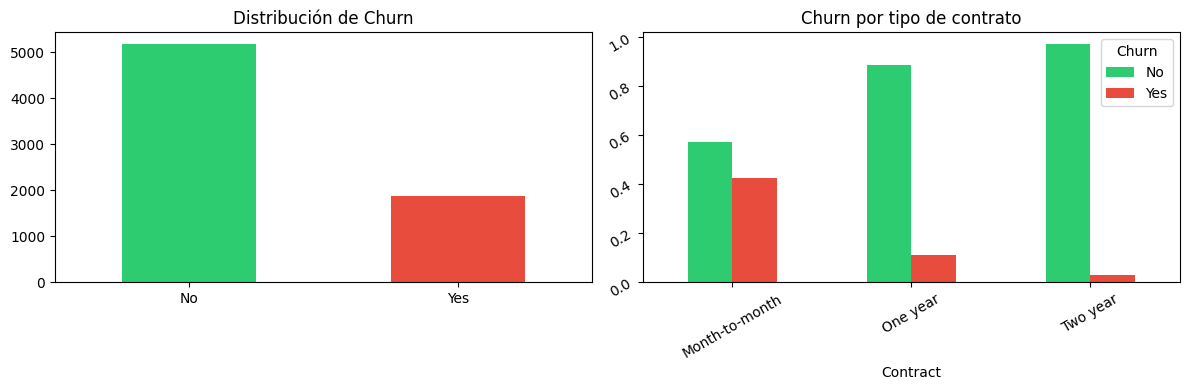

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de churn
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de Churn')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)

# Churn por tipo de contrato
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c']
)
axes[1].set_title('Churn por tipo de contrato')
axes[1].tick_params(rotation=30)

plt.tight_layout()
plt.savefig('../data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Celda 5 — Correlaciones numéricas

=== Correlación con Churn ===
tenure           -0.352229
TotalCharges     -0.199484
MonthlyCharges    0.193356
Churn_bin         1.000000
Name: Churn_bin, dtype: float64


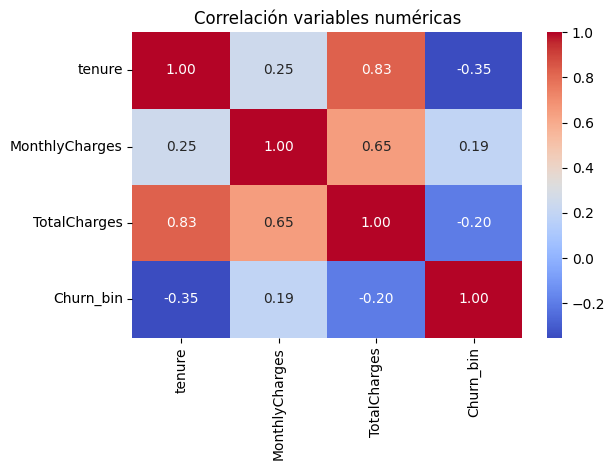

In [12]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_num = df[numeric_cols + ['Churn']].copy()
df_num['Churn_bin'] = (df_num['Churn'] == 'Yes').astype(int)

print("=== Correlación con Churn ===")
print(df_num[numeric_cols + ['Churn_bin']].corr()['Churn_bin'].sort_values())

sns.heatmap(df_num[numeric_cols + ['Churn_bin']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación variables numéricas')
plt.tight_layout()
plt.show()